> # Football Data Analysis
This dataset functions as a seasonal player-performance aggregation table, designed to track individual player statistics across different competitions and teams.
   - **Kaggle Dataset Link** -https://www.kaggle.com/datasets/xfkzujqjvx97n/football-datasets

# Football Performance Dataset Schema
> **Dataset Overview:** This schema acts as a standard seasonal player-performance aggregation table to track individual player statistics across various competitions and teams.

---

### 1. Core Identifiers & Metadata
These columns provide the foundational context for each record, linking performance stats to specific players, seasons, and teams.

| Column Name | Description |
| :--- | :--- |
| **`player_id`** | Unique identifier for the individual player. Essential for joining performance stats with master player biographical data (e.g., name, age, nationality, preferred foot). |
| **`season_name`** | The specific football season being recorded (e.g., "2025/2026"). |
| **`competition_id`** | Unique identifier for the specific tournament or league. |
| **`competition_name`** | The human-readable name of the competition (e.g., "English Premier League", "UEFA Champions League"). |
| **`team_id`** | Unique identifier for the club or national team the player represented during these matches. |
| **`team_name`** | The name of the team (e.g., "Real Madrid", "Arsenal"). |

---

### 2. Squad Selection & Participation
Metrics that track player availability, match selection, and physical time spent on the pitch.

* **`nb_in_group`** *(Number in Group/Squad)*: Total number of matchday squads the player was named to, covering both starting lineups and the bench.
* **`nb_on_pitch`** *(Number on Pitch)*: Total number of matches where the player actually stepped onto the field (Starts + Subbed in).
* **`subed_in`** *(Subbed In)*: Number of times the player started on the bench but was brought on as a substitute.
* **`subed_out`** *(Subbed Out)*: Number of times the player started the match but was substituted off before the final whistle.
* **`minutes_played`**: The total cumulative duration (in minutes) the player spent on the pitch during the specified season and competition.

---

### 3. Attacking & Goal Scoring Metrics
Primary KPIs used to analyze offensive production and goal contributions.

* **`goals`**: Total number of goals scored by the player (includes open-play, headers, free-kicks, and penalties).
* **`assists`**: Number of goal assists credited to the player (the final pass leading directly to a goal).
* **`penalty_goals`**: Subset of the player's total goals scored directly from penalty kicks. *Note: Crucial for isolating open-play efficiency.*
* **`own_goals`**: Number of times the player accidentally scored against their own team.

---

### 4. Discipline Metrics
Indicators for evaluating player reliability, defensive aggression, and potential team risk factors.

* **`yellow_cards`**: Total number of single yellow cards received across the matches.
* **`second_yellow_cards`**: Number of times a player received a second yellow in a single match, resulting in an indirect red card.
* **`direct_red_cards`**: Number of straight red cards shown for severe fouls, misconduct, or denying obvious goal opportunities.

---

### 5. Defensive & Goalkeeping Metrics
*Note: While these columns are present across all rows, they serve as the primary benchmarks for evaluating Goalkeepers and Defenders.*

* **`goals_conceded`**: Total number of goals let in by the team while this specific player was actively on the pitch.
* **`clean_sheets`**: Number of full matches where the team did not concede a single goal while the player was participating.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [20]:
df = pd.read_csv("player_performances.csv")
df.head(1)

,player_id,season_name,competition_id,competition_name,team_id,team_name,nb_in_group,nb_on_pitch,goals,assists,own_goals,subed_in,subed_out,yellow_cards,second_yellow_cards,direct_red_cards,penalty_goals,minutes_played,goals_conceded,clean_sheets
0,1,08/09,OBLG,NOFV-Oberliga Süd,4825,FC Eilenburg,9,9,0.0,0,0,0,2,0,0,1,0,NaN,0,0


> # About This DataSet

- **Row** : 1878719
- **Columns** : 20
   - int   14
   - object  4
   - float 2

In [21]:
df.columns.to_list()

['player_id',
 'season_name',
 'competition_id',
 'competition_name',
 'team_id',
 'team_name',
 'nb_in_group',
 'nb_on_pitch',
 'goals',
 'assists',
 'own_goals',
 'subed_in',
 'subed_out',
 'yellow_cards',
 'second_yellow_cards',
 'direct_red_cards',
 'penalty_goals',
 'minutes_played',
 'goals_conceded',
 'clean_sheets']

In [22]:
df.shape

(1878719, 20)

In [ ]:
#data Inspect
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1878719 entries, 0 to 1878718
Data columns (total 20 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   player_id            1878719 non-null  int64  
 1   season_name          1878719 non-null  object 
 2   competition_id       1878719 non-null  object 
 3   competition_name     1878719 non-null  object 
 4   team_id              1878719 non-null  int64  
 5   team_name            1878719 non-null  object 
 6   nb_in_group          1878719 non-null  int64  
 7   nb_on_pitch          1878719 non-null  int64  
 8   goals                1740517 non-null  float64
 9   assists              1878719 non-null  int64  
 10  own_goals            1878719 non-null  int64  
 11  subed_in             1878719 non-null  int64  
 12  subed_out            1878719 non-null  int64  
 13  yellow_cards         1878719 non-null  int64  
 14  second_yellow_cards  1878719 non-null  int64  
 15

In [24]:
df.dtypes.value_counts()

int64      14
object      4
float64     2
Name: count, dtype: int64

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
player_id,1878719.0,291629.480617,292207.879140,1.0,55494.0,189482.0,447768.0,1453181.0
team_id,1878719.0,10692.977300,17703.140043,1.0,798.0,3060.0,11449.0,134550.0
nb_in_group,1878719.0,9.929085,10.843456,1.0,2.0,4.0,16.0,51.0
nb_on_pitch,1878719.0,8.156783,9.865284,0.0,1.0,3.0,13.0,51.0
goals,1740517.0,0.952719,2.283932,0.0,0.0,0.0,1.0,50.0
assists,1878719.0,0.446945,1.247370,0.0,0.0,0.0,0.0,29.0
own_goals,1878719.0,0.015329,0.130054,0.0,0.0,0.0,0.0,9.0
subed_in,1878719.0,1.673163,3.035122,0.0,0.0,0.0,2.0,38.0
subed_out,1878719.0,1.855993,3.260543,0.0,0.0,1.0,2.0,40.0
yellow_cards,1878719.0,1.111522,1.919704,0.0,0.0,0.0,1.0,21.0


In [ ]:
df.describe(include=['object'])

,season_name,competition_id,competition_name,team_name
count,1878719,1878719,1878719,1878719
unique,102,1643,1988,15411
top,22/23,FAC,FA Cup,Arsenal FC
freq,106476,40958,40958,4063


In [27]:
df.count()

player_id              1878719
season_name            1878719
competition_id         1878719
competition_name       1878719
team_id                1878719
team_name              1878719
nb_in_group            1878719
nb_on_pitch            1878719
goals                  1740517
assists                1878719
own_goals              1878719
subed_in               1878719
subed_out              1878719
yellow_cards           1878719
second_yellow_cards    1878719
direct_red_cards       1878719
penalty_goals          1878719
minutes_played          708161
goals_conceded         1878719
clean_sheets           1878719
dtype: int64

> ## DATASET ISSUE

- **Player Id , Competition id  , team id ,**  need to delete nned to be remove
- **Goals 62.3% , Count = 1170558 and min_played 7.3% , Count = 138202** contains missing value
- 

In [29]:
df.head(5)

,player_id,season_name,competition_id,competition_name,team_id,team_name,nb_in_group,nb_on_pitch,goals,assists,own_goals,subed_in,subed_out,yellow_cards,second_yellow_cards,direct_red_cards,penalty_goals,minutes_played,goals_conceded,clean_sheets
0,1,08/09,OBLG,NOFV-Oberliga Süd,4825,FC Eilenburg,9,9,0.0,0,0,0,2,0,0,1,0,NaN,0,0
1,1,07/08,RS,Regionalliga Süd,1526,FSV Ludwigshafen Oggersheim,22,22,1.0,0,0,3,8,1,0,0,0,1580.0,0,0
2,1,06/07,L2,2. Bundesliga,996,TuS Koblenz,10,4,0.0,0,0,4,0,0,0,0,0,NaN,0,0
3,1,06/07,DFB,DFB-Pokal,996,TuS Koblenz,1,0,0.0,0,0,0,0,0,0,0,0,NaN,0,0
4,1,05/06,L2,2. Bundesliga,66,SpVgg Unterhaching,26,14,1.0,1,0,12,1,1,0,0,0,388.0,0,0


> NUll Value analysis

In [ ]:

# counting the sum of missing value per col
df.isna().sum()

player_id                    0
season_name                  0
competition_id               0
competition_name             0
team_id                      0
team_name                    0
nb_in_group                  0
nb_on_pitch                  0
goals                   138202
assists                      0
own_goals                    0
subed_in                     0
subed_out                    0
yellow_cards                 0
second_yellow_cards          0
direct_red_cards             0
penalty_goals                0
minutes_played         1170558
goals_conceded               0
clean_sheets                 0
dtype: int64

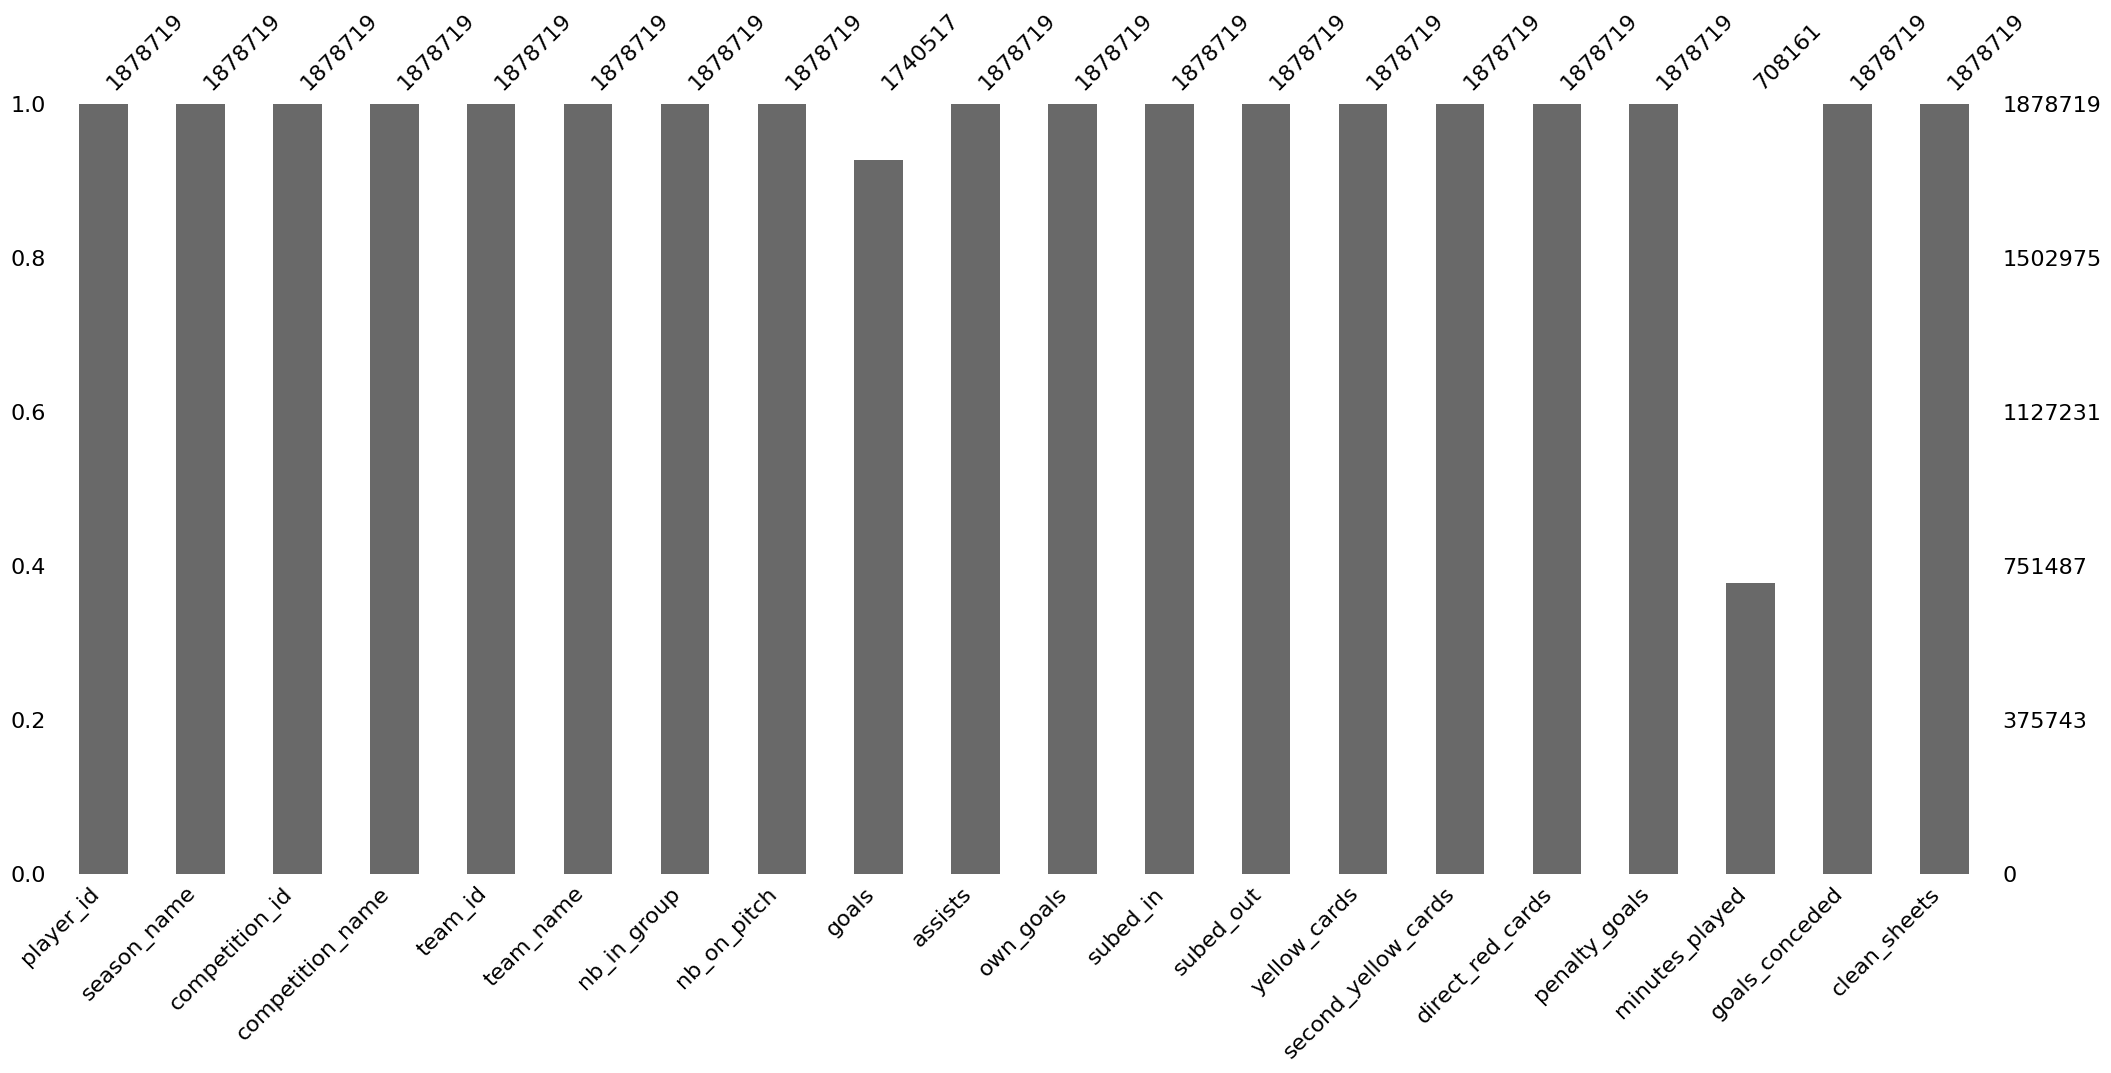

In [56]:
#missing value bar visualization
msno.bar(df)
plt.show()

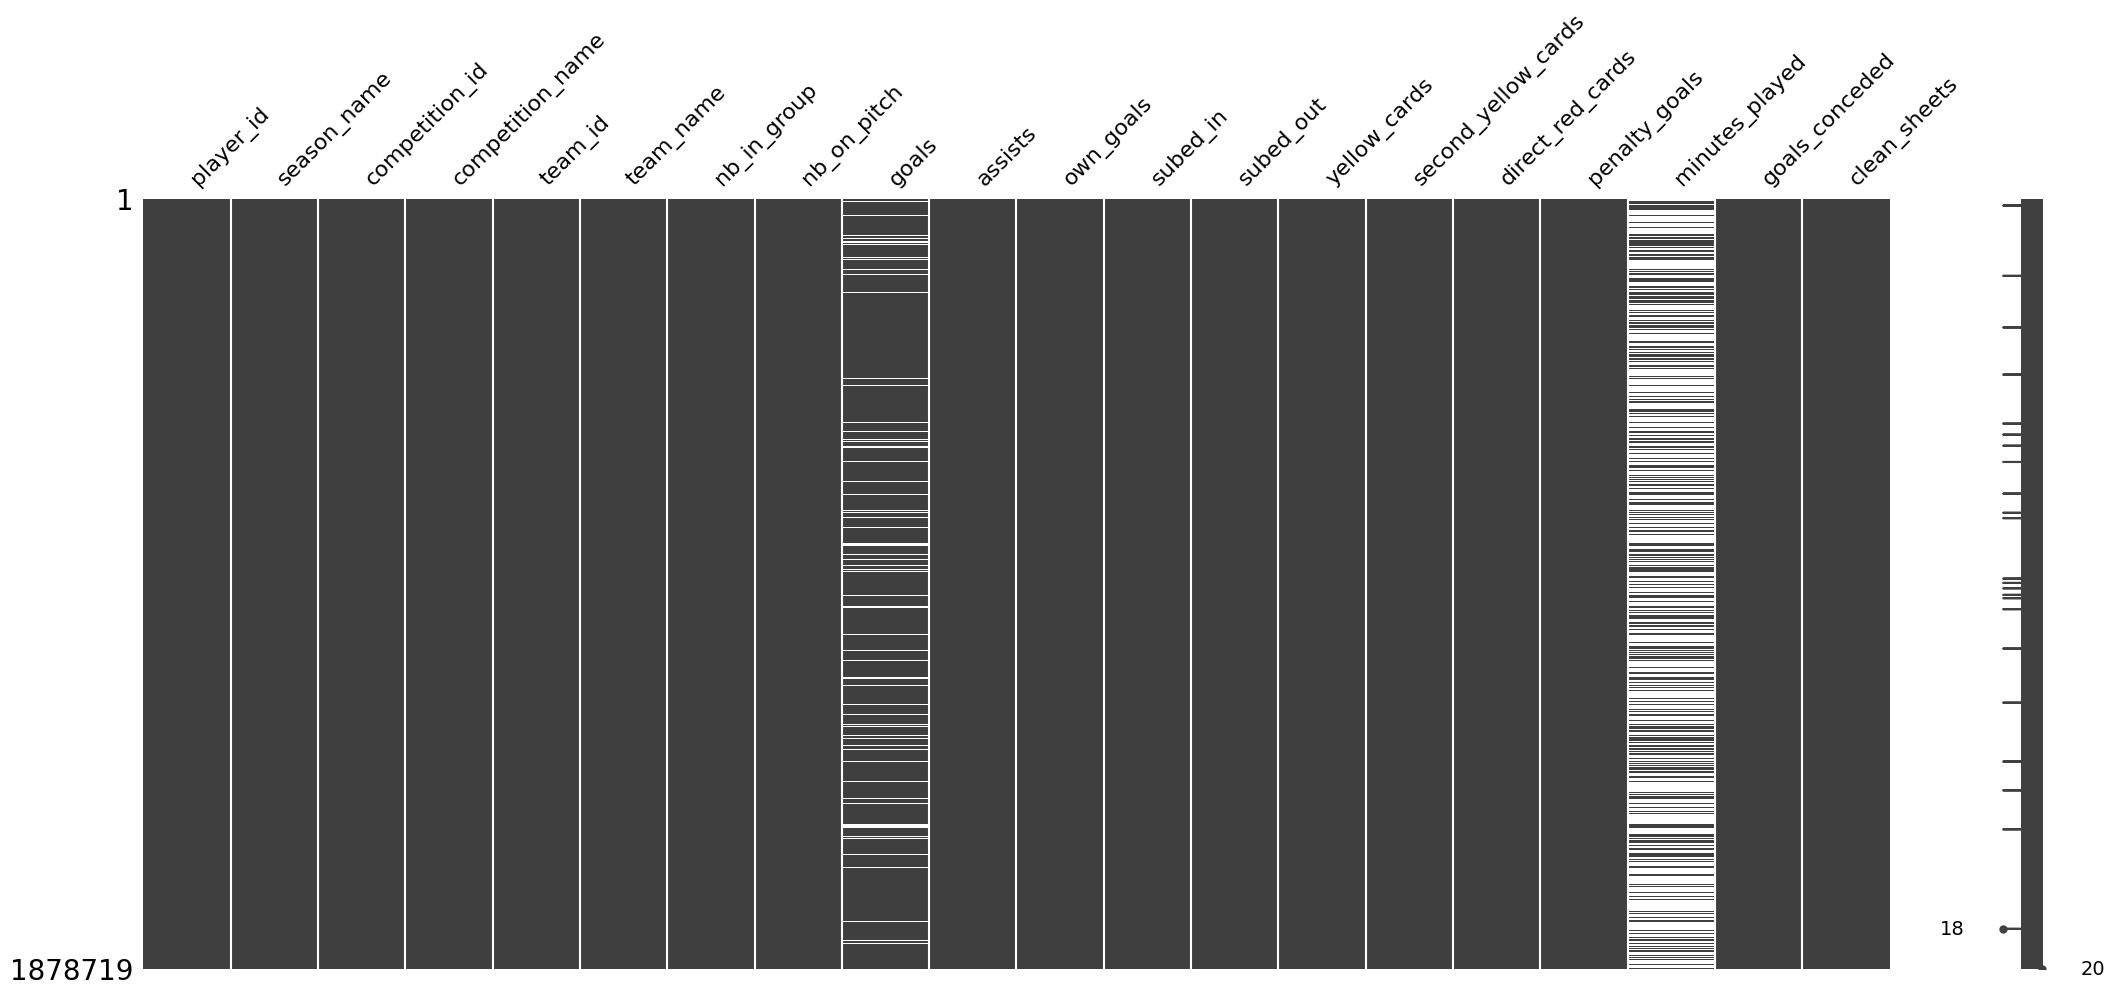

In [48]:

# missing value visualization
msno.matrix(df)
plt.show()

In [ ]:
# Missing Value percentage

missing_value = df.isna().sum()
missing_value_percentage = 100*missing_value/len(df)
missing_value_percentage = missing_value_percentage.round(2).sort_values(ascending=False)
missing_value_percentage = missing_value_percentage[missing_value_percentage.values>0]
missing_value_percentage.reset_index()

,index,0
0,minutes_played,62.31
1,goals,7.36


In [55]:
# data Frame of missing value
missing_df = pd.DataFrame(
    {
        "Missing_Count" : missing_value,
        "Percentage" : missing_value_percentage
    }
)
missing_df = missing_df[missing_df['Missing_Count']>0].sort_values(by = "Missing_Count",ascending=False)
missing_df

,Missing_Count,Percentage
minutes_played,1170558,62.31
goals,138202,7.36
